# Exploratory Data Analysis (EDA)

Данный ноутбук посвящён исследованию статистических и структурных характеристик используемых временных рядов.

Основное внимание уделяется:
* структуре временного ряда,
* сезонности и трендам,
* свойствам распределения,
* диагностике стационарности.

На этом этапе модели прогнозирования не обучаются.

In [127]:
%pip install statsmodels


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [128]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL

Подгрузим "сырые" данные, подготовленные в предыдущем ноутбуке.

In [146]:
def load_csv_ts(path, datetime_col="timestamp"):
    df = pd.read_csv(
        path,
        parse_dates=[datetime_col],
        index_col=datetime_col,
    )

    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")

    df = df.sort_index()

    return df

In [147]:
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "raw"

In [149]:
day_ahead_prices_df = load_csv_ts(
    PROCESSED_DIR / "entsoe/nl_day_ahead_prices_hourly_2019_2025.csv"
)

load_df = load_csv_ts(
    PROCESSED_DIR / "entsoe/nl_load_hourly_2019_2025.csv"
)

solar_df = load_csv_ts(
    PROCESSED_DIR / "entsoe/nl_solar_generation_hourly_2019_2025.csv"
)

wind_df = load_csv_ts(
    PROCESSED_DIR / "entsoe/nl_wind_generation_hourly_2019_2025.csv"
)

weather_df = load_csv_ts(
    PROCESSED_DIR / "weather/weather_hourly_nl_open_meteo_2019_2025.csv"
)

gas_df = load_csv_ts(
    PROCESSED_DIR / "gas/ttf_gas_price_daily_2019_2025.csv",
    datetime_col="date"
)

In [154]:
day_ahead_prices_df.head()

,day_ahead_price
timestamp,
2018-12-31 23:00:00+00:00,68.92
2019-01-01 00:00:00+00:00,64.98
2019-01-01 01:00:00+00:00,60.27
2019-01-01 02:00:00+00:00,49.97
2019-01-01 03:00:00+00:00,47.66


In [155]:
day_ahead_prices_df.index.to_series().diff().value_counts().head(10)

timestamp
0 days 01:00:00    59147
0 days 00:15:00     8834
0 days 02:00:00        6
0 days 00:30:00        1
Name: count, dtype: int64

## Обработка пропущенных значений

В первую очередь давайте соберем все временные ряды в один словарь, чтобы было проще обрабатывать:

In [167]:
datasets = {
    "price": day_ahead_prices_df,
    "load": load_df,
    "solar": solar_df,
    "wind": wind_df,
    "gas": gas_df,
    "weather": weather_df,
}

Проверим пропуски:

In [168]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.isna().sum())
    print((df.isna().mean() * 100).round(4))


PRICE
day_ahead_price    0
dtype: int64
day_ahead_price    0.0
dtype: float64

LOAD
load_mw    0
dtype: int64
load_mw    0.0
dtype: float64

SOLAR
solar_mw    0
dtype: int64
solar_mw    0.0
dtype: float64

WIND
wind_mw    0
dtype: int64
wind_mw    0.0
dtype: float64

GAS
gas_price    0
dtype: int64
gas_price    0.0
dtype: float64

WEATHER
temperature_c    0
wind_ms          0
dtype: int64
temperature_c    0.0
wind_ms          0.0
dtype: float64


Пропусков нет. Далее проверим временную структуры каждого ряда, включая анализ периодичности временных меток и регулярности наблюдений.

In [169]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(pd.infer_freq(df.index))


price
None

load
15min

solar
15min

wind
15min

gas
None

weather
h


In [170]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.index.to_series().diff().value_counts().head(10))


PRICE
timestamp
0 days 01:00:00    59147
0 days 00:15:00     8834
0 days 02:00:00        6
0 days 00:30:00        1
Name: count, dtype: int64

LOAD
timestamp
0 days 00:15:00    245471
Name: count, dtype: int64

SOLAR
timestamp
0 days 00:15:00    245471
Name: count, dtype: int64

WIND
timestamp
0 days 00:15:00    245471
Name: count, dtype: int64

GAS
date
1 days    1379
3 days     318
4 days      46
2 days      16
5 days       1
Name: count, dtype: int64

WEATHER
timestamp
0 days 01:00:00    61367
Name: count, dtype: int64


Анализ фактических временных интервалов между наблюдениями показал, что исходные данные представлены с различной временной частотой.

Данные нагрузки и генерации (солнечной и ветровой) представлены с 15-минутным разрешением. Погодные данные имеют регулярную почасовую структуру без пропусков. Газовые цены представлены с дневной частотой торговых дней, что соответствует особенностям торгового календаря.

Для временного ряда цен электроэнергии была выявлена смешанная структура временных интервалов: основной объём наблюдений представлен с почасовой частотой, однако присутствуют сегменты с более высокой частотой (15 минут), а также единичные отклонения, связанные с переходами летнего времени и отдельными артефактами данных.

Для обеспечения сопоставимости данных и корректной работы моделей все временные ряды приведем к единой почасовой частоте. Для рядов нагрузки и генерации используем агрегацию методом среднего значения. Для цен электроэнергии была выполним агрегацию к почасовому разрешению для устранения высокочастотных сегментов. Газовые цены были преобразуем в почасовой формат методом прямого распространения последнего известного значения.

In [171]:
def to_hourly(ts, how="mean"):
    if how == "mean":
        return ts.resample("h").mean()

    if how == "sum":
        return ts.resample("h").sum()

    if how == "ffill":
        return ts.resample("h").ffill()

    raise ValueError("Unknown method")

In [172]:
price_hourly = to_hourly(day_ahead_prices_df.iloc[:, 0], "mean")

load_hourly = to_hourly(load_df.iloc[:, 0], "mean")

solar_hourly = to_hourly(solar_df.iloc[:, 0], "mean")

wind_hourly = to_hourly(wind_df.iloc[:, 0], "mean")

weather_hourly = weather_df.resample("h").mean()


In [174]:
hourly_series = {
    "price": price_hourly,
    "load": load_hourly,
    "solar": solar_hourly,
    "wind": wind_hourly,
    "weather": weather_hourly.iloc[:, 0] if isinstance(weather_hourly, pd.DataFrame) else weather_hourly,
}

for name, ts in hourly_series.items():
    print(f"\n{name.upper()}")
    print(ts.index.to_series().diff().value_counts().head(10))


PRICE
timestamp
0 days 01:00:00    61368
Name: count, dtype: int64

LOAD
timestamp
0 days 01:00:00    61367
Name: count, dtype: int64

SOLAR
timestamp
0 days 01:00:00    61367
Name: count, dtype: int64

WIND
timestamp
0 days 01:00:00    61367
Name: count, dtype: int64

WEATHER
timestamp
0 days 01:00:00    61367
Name: count, dtype: int64


После приведения всех временных рядов к почасовой частоте был проведён анализ фактических временных интервалов между наблюдениями. Результаты показали, что все временные ряды имеют регулярную почасовую структуру без смешанных частот и высокочастотных сегментов. Это подтверждает корректность выполненной процедуры агрегации и обеспечивает сопоставимость данных для дальнейшего моделирования.

Теперь снова проверим, нет ли пустых значений:

In [181]:
for name, ts in hourly_series.items():
    nan_count = ts.isna().sum()
    nan_pct = ts.isna().mean() * 100

    print(f"\n{name}")
    print(f"NaN count: {nan_count}")
    print(f"NaN %: {nan_pct:.4f}")


price
NaN count: 6
NaN %: 0.0098

load
NaN count: 0
NaN %: 0.0000

solar
NaN count: 0
NaN %: 0.0000

wind
NaN count: 0
NaN %: 0.0000

weather
NaN count: 0
NaN %: 0.0000


In [182]:
price_hourly = price_hourly.ffill()

После приведения временных рядов к почасовой частоте в ряде цен электроэнергии было обнаружено менее 0.01% пропущенных значений. Учитывая их крайне малую долю и локальный характер, пропуски были заполнены методом прямого распространения предыдущего наблюдения.

## Общие функции первичного анализа временных рядов
На первом этапе анализа для всех временных рядов (как целевого ряда, так и регрессоров) применяются базовые функции первичного исследования данных. Цель данного этапа — получить общее представление о структуре рядов, их распределении, наличии пропусков, выбросов и возможных структурных изменений во времени.

Функция `basic_ts_info` используется для расчёта и вывода основных статистических характеристик ряда, включая количество наблюдений, наличие пропущенных значений, базовые описательные статистики (среднее значение, стандартное отклонение, минимальные и максимальные значения, квантили). Данный этап позволяет быстро выявить аномалии в данных, а также оценить общий масштаб и вариативность ряда.

In [185]:
def basic_ts_info(series: pd.Series) -> dict:
    s = series.copy()

    info = {}

    info["name"] = s.name
    info["start"] = s.index.min()
    info["end"] = s.index.max()
    info["n_rows"] = len(s)

    info["n_missing"] = int(s.isna().sum())
    info["pct_missing"] = float(s.isna().mean() * 100)

    info["min"] = float(s.min())
    info["max"] = float(s.max())
    info["mean"] = float(s.mean())
    info["std"] = float(s.std())

    if np.issubdtype(s.dtype, np.number):
        info["n_zeros"] = int((s == 0).sum())
        info["n_negative"] = int((s < 0).sum())
    else:
        info["n_zeros"] = None
        info["n_negative"] = None

    info["index_type"] = str(type(s.index))
    info["n_duplicate_timestamps"] = int(s.index.duplicated().sum())

    try:
        inferred_freq = pd.infer_freq(s.index)
    except:
        inferred_freq = None

    info["inferred_freq"] = inferred_freq

    if inferred_freq is not None:
        full_range = pd.date_range(start=s.index.min(), end=s.index.max(), freq=inferred_freq)
        info["n_missing_timestamps"] = int(len(full_range.difference(s.index)))
    else:
        info["n_missing_timestamps"] = None

    return info

Функция `plot_ts_ts` используется для визуального анализа временного ряда. Она позволяет построить график значений ряда во времени, что даёт возможность выявить тренды, сезонные паттерны, структурные сдвиги, а также периоды повышенной волатильности. Визуальный анализ особенно важен для обнаружения режимных изменений, которые могут быть связаны с внешними экономическими или рыночными событиями.

In [187]:
def plot_ts(
    ts,
    title,
    ylabel,
    main_color="tab:blue",
    rolling_window_hours=24*7,
    reference_periods=None,
):
    series = ts

    plt.style.use("seaborn-v0_8-whitegrid")

    fig, ax = plt.subplots(figsize=(16, 5))

    rolling = series.rolling(
        rolling_window_hours,
        center=True,
        min_periods=1
    ).mean()

    rolling.plot(
        ax=ax,
        color=main_color,
        linewidth=1.5,
        label=f"{rolling_window_hours//24}d rolling mean"
    )

    # Reference horizontal lines
    if reference_periods:
        for start, end, color, label in reference_periods:
            mean_val = series.loc[start:end].mean()
            ax.axhline(
                mean_val,
                color=color,
                linestyle="--",
                linewidth=2,
                label=f"{label}: {mean_val:.1f}"
            )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Period")

    ax.set_xlim(series.index.min(), series.index.max())
    ax.margins(y=0.05)

    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

## Анализ целевого временного ряда
Для целевого временного ряда проводится расширенный анализ временной структуры данных, направленный на выявление трендов, сезонных компонент, структурных сдвигов, а также проверку стационарности ряда. Данный этап необходим для корректного выбора методов моделирования и определения необходимости применения трансформаций данных.

Анализ целевого ряда включает следующие этапы.

Проверка стационарности временного ряда
Для оценки стационарности используются статистические тесты:

* тест Дики-Фуллера `adf_test`
* тест KPSS `kpss_test`

Тест Дики-Фуллера проверяет нулевую гипотезу о наличии единичного корня (нестационарности). Низкое значение p-value позволяет отвергнуть гипотезу нестационарности и сделать вывод о стационарности ряда.

Тест KPSS, напротив, проверяет нулевую гипотезу о стационарности ряда. Низкое значение p-value указывает на возможную нестационарность.

Совместное использование двух тестов позволяет повысить надёжность выводов о свойствах временного ряда.

In [188]:
def adf_test(timeseries, maxlag=None):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC", maxlag=maxlag)
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "# Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

Для анализа временной зависимости наблюдений используются:

* автокорреляционная функция (ACF)
* частичная автокорреляционная функция (PACF)

Для визуализации используется функция `plot_acf_pacf`, которая позволяет оценить:

* наличие автокорреляции
* возможные порядки AR и MA компонент
* сезонные зависимости

In [189]:
def plot_acf_pacf(series, lags=60, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(series, lags=lags, ax=axes[0])
    axes[0].set_title(f"{title_prefix} ACF")

    plot_pacf(series, lags=lags, method='ywm', ax=axes[1])
    axes[1].set_title(f"{title_prefix} ACF")

    plt.tight_layout()
    plt.show()

Для выявления сезонных паттернов проводится визуальный анализ ряда и анализ сезонных зависимостей по времени суток, дням недели и месяцам года. Это позволяет определить наличие краткосрочной и долгосрочной сезонности, характерной для почасовых энергетических рядов.

In [199]:
def plot_seasonality_ts(ts: pd.Series):

    df = ts.to_frame(name="value")

    dt = df.index

    df["hour"] = dt.hour
    df["weekday"] = dt.weekday
    df["month"] = dt.month

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    df.boxplot(column="value", by="hour", ax=axes[0])
    axes[0].set_title("Seasonality by Hour")
    axes[0].set_xlabel("Hour")

    df.boxplot(column="value", by="weekday", ax=axes[1])
    axes[1].set_title("Seasonality by Weekday")
    axes[1].set_xlabel("Weekday")

    df.boxplot(column="value", by="month", ax=axes[2])
    axes[2].set_title("Seasonality by Month")
    axes[2].set_xlabel("Month")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

In [203]:
def plot_seasonal_means_ts(ts: pd.Series):

    df = ts.to_frame(name="value")

    dt = df.index

    if not pd.api.types.is_datetime64_any_dtype(dt):
        dt = pd.to_datetime(dt)

    df["hour"] = dt.hour
    df["weekday"] = dt.weekday

    hourly_mean = df.groupby("hour")["value"].mean()
    weekday_mean = df.groupby("weekday")["value"].mean()

    plt.style.use("seaborn-v0_8-whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    hourly_mean.plot(ax=axes[0], linewidth=2)
    axes[0].set_title("Mean by Hour")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel(ts.name if ts.name else "value")

    weekday_mean.plot(ax=axes[1], linewidth=2)
    axes[1].set_title("Mean by Weekday")
    axes[1].set_xlabel("Weekday")
    axes[1].set_ylabel(ts.name if ts.name else "value")

    plt.tight_layout()
    plt.show()

Для разделения временного ряда на составляющие компоненты используется декомпозиция временного ряда (STL, MSTL). Декомпозиция позволяет выделить:

* трендовую компоненту
* сезонную компоненту
* остаточную компоненту

Анализ остаточной компоненты используется для оценки качества разложения и подготовки данных для последующего моделирования.

In [192]:
def stl_decompose(series, period=24, robust=True):
    stl = STL(series, period=period, robust=robust)
    res = stl.fit()

    res.plot()
    plt.show()

    return res

def mstl_decompose(series, periods=(24, 168)):
    mstl = MSTL(series, periods=periods)
    res = mstl.fit()

    res.plot()
    plt.show()

    return res

Для дополнительного анализа стабильности временного ряда используется анализ скользящих статистик, реализованный в функции `plot_rolling_stats`. Данный метод позволяет оценить изменение статистических характеристик ряда во времени и используется как инструмент первичной диагностики возможных структурных сдвигов.

Функция рассчитывает скользящее среднее значение и скользящее стандартное отклонение на заданном временном окне. Для почасовых данных в энергетике в качестве окна часто используется период порядка одного месяца, что позволяет сгладить краткосрочные колебания и выявить долгосрочные изменения в поведении ряда.

In [193]:
def plot_rolling_stats(series, window=24*30):
    roll_mean = series.rolling(window).mean()
    roll_std = series.rolling(window).std()

    plt.figure(figsize=(12, 5))
    plt.plot(series, label="Original", alpha=0.5)
    plt.plot(roll_mean, label="Rolling Mean")
    plt.plot(roll_std, label="Rolling Std")

    plt.legend()
    plt.title("Rolling Statistics")
    plt.show()

Дополнительно проводится анализ структурных изменений во временном ряде, включая выявление периодов аномальной волатильности и возможных режимных изменений. Особое внимание уделяется периоду рыночных шоков, которые могли привести к изменению механизма формирования цен.

Результаты данного анализа используются для принятия решения о формировании обучающего набора данных и выборе временных интервалов для обучения моделей.

Приступим к анализу нашего временного ряда price_hourly

In [194]:
basic_ts_info(price_hourly)

{'name': 'day_ahead_price',
 'start': Timestamp('2018-12-31 23:00:00+0000', tz='UTC'),
 'end': Timestamp('2025-12-31 23:00:00+0000', tz='UTC'),
 'n_rows': 61369,
 'n_missing': 0,
 'pct_missing': 0.0,
 'min': -500.0,
 'max': 872.96,
 'mean': 96.85852648188282,
 'std': 92.10679808038205,
 'n_zeros': 258,
 'n_negative': 1613,
 'index_type': "<class 'pandas.DatetimeIndex'>",
 'n_duplicate_timestamps': 0,
 'inferred_freq': 'h',
 'n_missing_timestamps': 0}

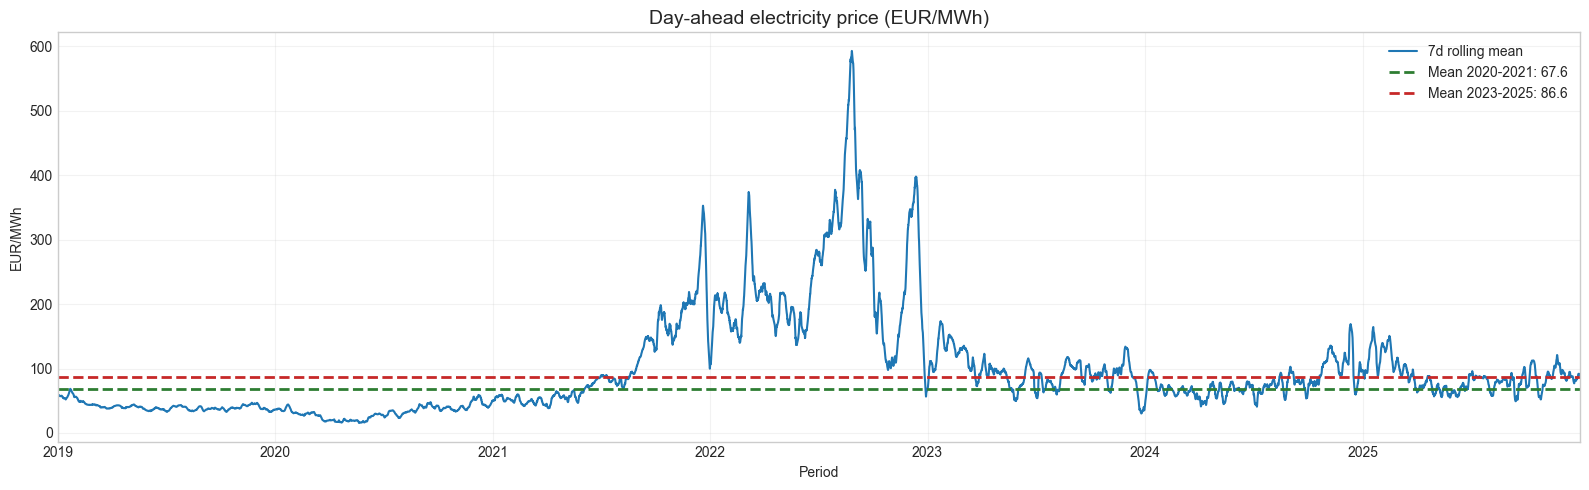

In [195]:
plot_ts(
    price_hourly,
    title="Day-ahead electricity price (EUR/MWh)",
    ylabel="EUR/MWh",
    main_color="tab:blue",
    reference_periods=[
        ("2020", "2021", "#2E7D32", "Mean 2020-2021"),
        ("2023", "2025", "#C62828", "Mean 2023-2025"),
    ]
)

По визуализации можно судить о том, что ряд демонстрирует сильную временную изменчивость и периоды повышенной волатильности.

* Виден структурный сдвиг уровня цен после 2021 года.
* 2022 год выделяется экстремальными пиками и высокой дисперсией
* После 2022 цены стабилизируются, но средний уровень остаётся выше докризисного
* Наблюдаются отрицательные цены и экстремальные выбросы, что характерно для электроэнергетических рынков
* Визуально ряд выглядит нестационарным (меняется уровень и волатильность)

In [196]:
adf_test(price_hourly)
kpss_test(price_hourly)

Results of Dickey-Fuller Test:
Test Statistic                -7.466633e+00
p-value                        5.183794e-11
# Lags Used                    6.000000e+01
Number of Observations Used    6.130800e+04
Critical Value (1%)           -3.430457e+00
Critical Value (5%)           -2.861587e+00
Critical Value (10%)          -2.566795e+00
dtype: float64
Results of KPSS Test:
Test Statistic             6.490286
p-value                    0.010000
Lags Used                140.000000
Critical Value (10%)       0.347000
Critical Value (5%)        0.463000
Critical Value (2.5%)      0.574000
Critical Value (1%)        0.739000
dtype: float64


/var/folders/jm/fc2yd4bx6r10m1j2gh1r3dq40000gn/T/ipykernel_23445/2462780619.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


Тест Дики–Фуллера отвергает нулевую гипотезу о наличии единичного корня, что указывает на то, что ряд цен на электроэнергию не ведёт себя как классический случайный блуждающий процесс. Однако тест KPSS отвергает нулевую гипотезу о стационарности уровня, что означает, что ряд не является стационарным по среднему значению и/или дисперсии во времени. Совместная интерпретация результатов показывает, что, несмотря на отсутствие признаков классического unit root процесса, ряд всё же демонстрирует нестационарное поведение, связанное со структурными изменениями, сменой режимов и кластеризацией волатильности. Такой вывод согласуется с результатами визуального анализа, где наблюдаются существенные изменения уровня цен и волатильности, особенно в период энергетического кризиса 2022 года и последующей стабилизации на более высоком среднем уровне цен.

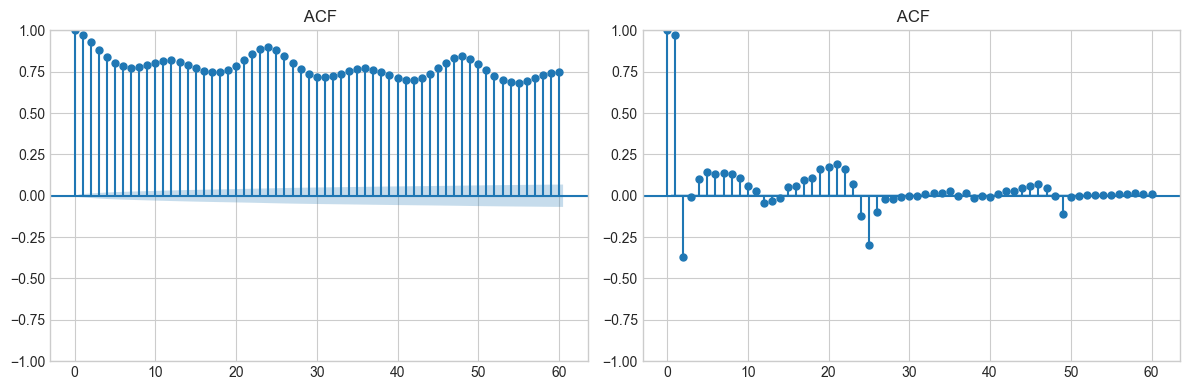

In [200]:
plot_acf_pacf(price_hourly)

Автокорреляционная функция (ACF) демонстрирует медленно затухающую зависимость и остаётся значимо положительной на большом числе лагов, что указывает на высокую персистентность ряда и согласуется с гипотезой о его нестационарности по уровню. Дополнительно наблюдается волнообразная структура автокорреляций, что может свидетельствовать о наличии сезонных компонент в данных. Частичная автокорреляционная функция (PACF) показывает значимый вклад первых лагов с последующим быстрым затуханием, что может указывать на наличие краткосрочной авторегрессионной структуры. Совокупность этих наблюдений согласуется с результатами тестов стационарности и визуального анализа и указывает на сложную динамическую структуру ряда, включающую сезонные эффекты, возможные структурные сдвиги и смену режимов.

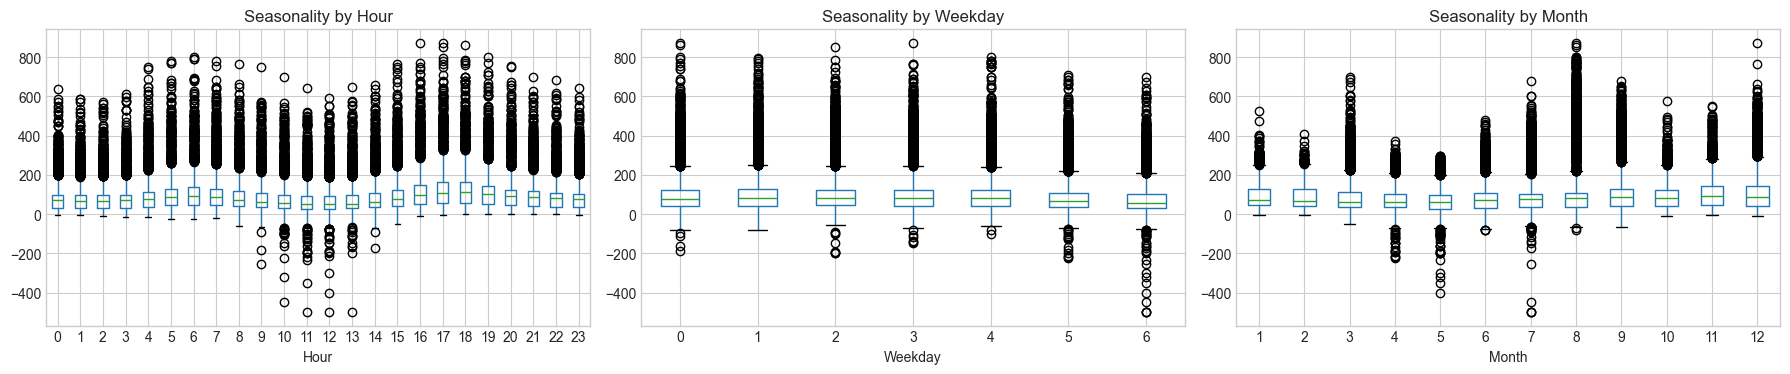

In [202]:
plot_seasonality_ts(price_hourly)

Анализ распределения цен по часам, дням недели и месяцам показывает наличие выраженной многомасштабной сезонности. Суточный паттерн является наиболее заметным: минимальные значения цен, как правило, наблюдаются в ночные часы, после чего следует рост в утренние часы и формирование более выраженного пика во второй половине дня и вечером. Также в дневные и вечерние часы наблюдается увеличение разброса значений, что указывает на рост волатильности в периоды высокой нагрузки. Отрицательные цены чаще встречаются в дневные часы, что может быть связано с высокой выработкой возобновляемой генерации при относительно низком уровне спроса.

Недельная сезонность выражена слабее: в будние дни в среднем наблюдаются немного более высокие цены и больший разброс значений по сравнению с выходными, что соответствует более высокой экономической активности и уровню спроса. Тем не менее, данный эффект носит вторичный характер по сравнению с суточной динамикой.

Годовая сезонность проявляется в более высоких медианных значениях и увеличенной волатильности в зимние месяцы, что связано с общим ростом спроса и сезонными особенностями генерации. Летние месяцы характеризуются более низким средним уровнем цен, при этом возможны отдельные экстремальные значения, обусловленные погодными условиями. Переходные сезоны демонстрируют промежуточное поведение. В совокупности сезонные эффекты являются одной из ключевых характеристик ряда и должны учитываться при построении моделей прогнозирования.

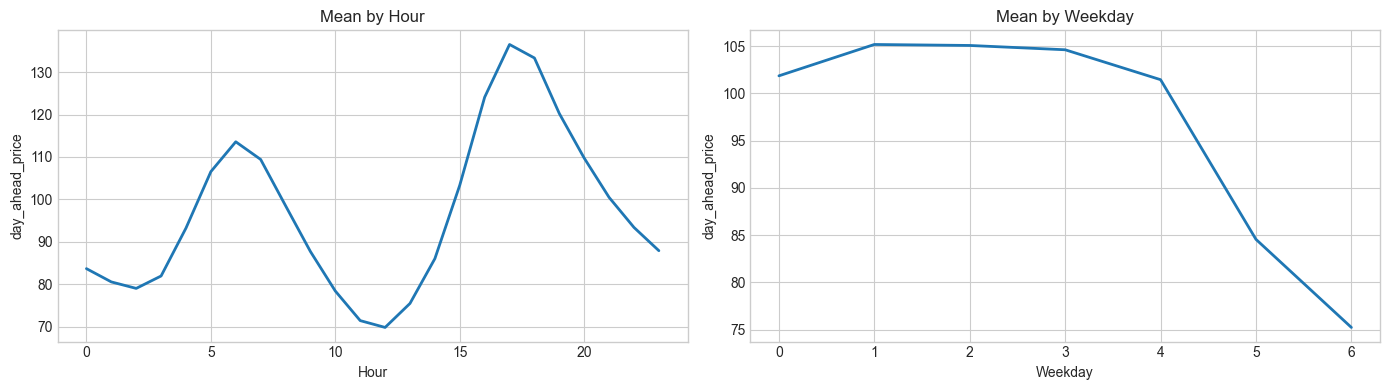

In [204]:
plot_seasonal_means_ts(price_hourly)

Что можно сказать по внутрисуточной сезонности. Есть очень чёткая форма:

* Ночь (0–4)
Цена ниже средней, что логично, так как спрос минимальный, генерация стабильная, рынок спокоен.

* Утренний рост (5–8)
Резкий подъём, так как люди и предприятия просыпаются, и спрос растёт быстрее генерации.

* Дневной провал (10–13)
Минимум примерно около 11–12. Очень типично для стран с солнечной генерацией, так как солнечная генерация снижает цену.

* Вечерний пик (16–19)
Самые высокие значения дня, так как солнце падает, но спрос всё ещё высокий, и приходится включать дорогую генерацию

Что можно сказать по недельной сезонности:

* Пн–Ср максимум. Промышленность и бизнес нагрузка.
* Чт–Пт плавное снижение.
* Сб–Вс сильное падение. Минимум в воскресенье.

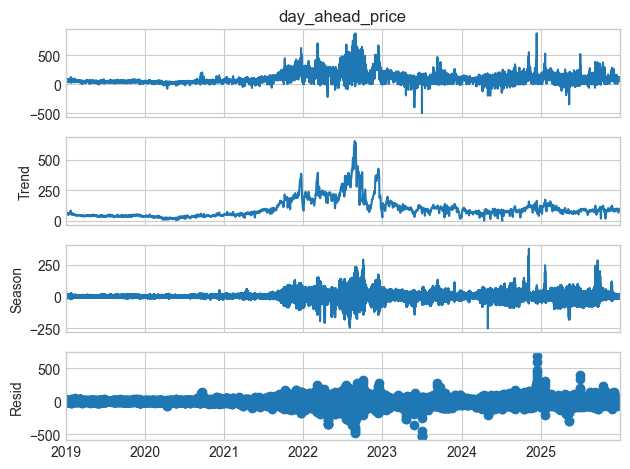

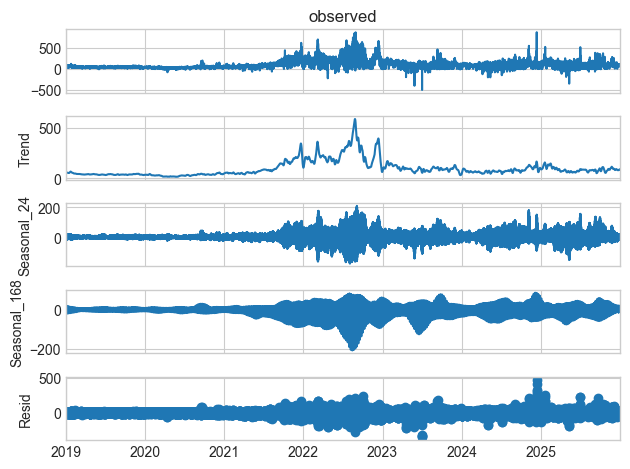

In [206]:
stl_decompose(price_hourly, period=24)
mstl_decompose(price_hourly, periods=(24, 168))

Декомпозиция временного ряда показывает наличие выраженного долгосрочного тренда с резким ростом в 2021–2022 годах и последующей стабилизацией на более высоком уровне. Наблюдается устойчивая суточная сезонность с максимумами в вечерние часы и минимумами в ночной период, а также менее выраженная недельная сезонность с более высокими значениями в рабочие дни. Амплитуда сезонных компонент изменяется во времени и увеличивается в периоды повышенной волатильности, что согласуется с гипотезой о нестационарности ряда и наличии структурных сдвигов. Остаточная компонента содержит выбросы и периоды повышенной волатильности, особенно в 2022 году, что может отражать влияние внешних рыночных шоков.

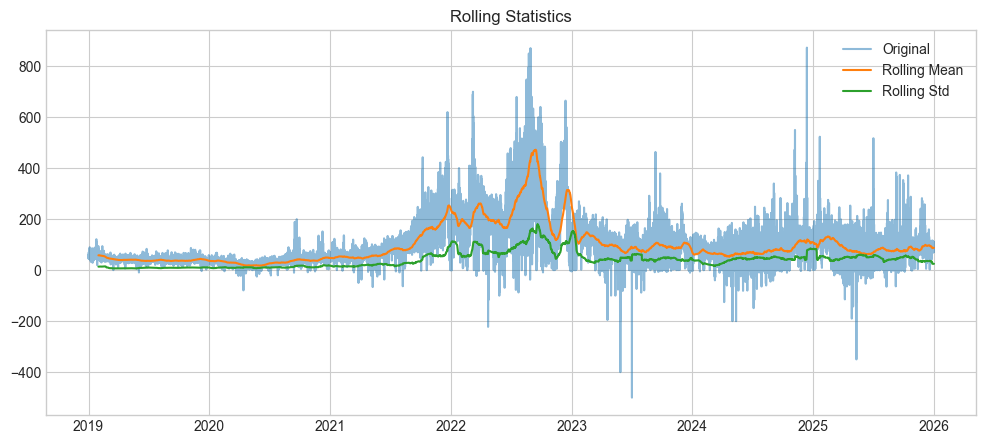

In [207]:
plot_rolling_stats(price_hourly)

Анализ скользящих статистик указывает на выраженную нестационарность временного ряда как по среднему значению, так и по дисперсии. В 2021–2022 годах наблюдается резкий рост среднего уровня цен и существенное увеличение волатильности. После 2023 года показатели частично стабилизируются, однако остаются выше докризисного уровня. Это свидетельствует о наличии структурных сдвигов и изменении режима поведения рынка электроэнергии.

#### Вывод
В ходе разведочного анализа было выявлено, что временной ряд цен содержит периоды с различными режимами поведения, включая аномальные условия рынка в 2021–2022 годах. Поскольку такие структурные сдвиги могут существенно влиять на качество прогнозирования и обобщающую способность моделей, в дальнейшем рассматриваются два варианта обучающего набора данных:

* Полный период наблюдений (2019–2025) используется для оценки способности моделей учитывать долгосрочные изменения и редкие экстремальные режимы
* Стабилизированный период (2023–2025) используется для построения моделей, ориентированных на актуальные рыночные условия, и снижения влияния аномальных режимов на обучение

Далее модели обучаются и сравниваются на обоих вариантах датасетов с использованием единой схемы валидации и метрик качества. Это позволяет количественно оценить влияние выбора периода обучения на точность прогнозирования и устойчивость моделей.

## Анализ экзогенных переменных

Помимо анализа целевого временного ряда, проводится анализ экзогенных переменных, используемых в качестве регрессоров в моделях прогнозирования. Экзогенные переменные представляют собой внешние факторы, которые могут оказывать влияние на поведение целевого показателя и позволяют повысить точность прогнозирования.

Для первичной оценки сезонной структуры экзогенных переменных используется функция `plot_seasonal_boxplots`. Данная функция позволяет визуализировать распределение значений переменной в разрезе часа суток, дня недели и месяца года.

Анализ сезонного распределения позволяет выявить наличие повторяющихся паттернов во временном ряде, а также оценить вариативность значений внутри каждого сезонного периода. Использование boxplot-визуализации позволяет дополнительно выявлять выбросы и оценивать стабильность распределения значений во времени.

In [214]:
def plot_seasonal_boxplots(df, value_col, datetime_col):
    df = df.copy()

    df["hour"] = df[datetime_col].dt.hour
    df["weekday"] = df[datetime_col].dt.weekday
    df["month"] = df[datetime_col].dt.month

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    df.boxplot(column=value_col, by="hour", ax=axes[0])
    axes[0].set_title("By Hour")

    df.boxplot(column=value_col, by="weekday", ax=axes[1])
    axes[1].set_title("By Weekday")

    df.boxplot(column=value_col, by="month", ax=axes[2])
    axes[2].set_title("By Month")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

Для дополнительного анализа сезонной структуры используется функция plot_seasonal_means, которая строит средние значения переменной в зависимости от часа суток и дня недели.

Данный анализ позволяет выявить типичный сезонный профиль переменной и оценить стабильность сезонных зависимостей. В отличие от анализа распределения, данный подход позволяет более наглядно выявить форму сезонного паттерна и оценить его влияние на поведение переменной.

In [215]:
def plot_seasonal_means(df, value_col, datetime_col):
    df = df.copy()

    df["hour"] = df[datetime_col].dt.hour
    df["weekday"] = df[datetime_col].dt.weekday

    hourly_mean = df.groupby("hour")[value_col].mean()
    weekday_mean = df.groupby("weekday")[value_col].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    hourly_mean.plot(ax=axes[0], title="Mean by Hour")
    weekday_mean.plot(ax=axes[1], title="Mean by Weekday")

    plt.tight_layout()
    plt.show()

Для количественной оценки выраженности сезонной структуры используется функция `check_basic_seasonality_strength`. Данная функция рассчитывает отношение дисперсии средних значений по сезонным группам к общей дисперсии ряда.

Полученный показатель позволяет оценить вклад сезонной компоненты в общую вариативность временного ряда. Более высокие значения показателя свидетельствуют о более выраженной сезонной структуре.

In [216]:
def check_basic_seasonality_strength(df, value_col, datetime_col):
    df = df.copy()
    df["hour"] = df[datetime_col].dt.hour

    overall_var = df[value_col].var()
    hourly_var = df.groupby("hour")[value_col].mean().var()

    strength = hourly_var / overall_var

    print(f"Hourly seasonality strength ratio: {strength:.3f}")

С помощью `correlation_with_target` проводится анализ взаимосвязи между экзогенными переменными и целевым временным рядом. Цель анализа — оценить степень влияния внешних факторов на поведение целевого показателя, а также выявить возможные временные лаги между изменениями экзогенных переменных и реакцией целевого ряда.

In [220]:
def correlation_with_target(ts: pd.Series, target_ts: pd.Series):
    aligned = pd.concat([ts, target_ts], axis=1).dropna()
    aligned.columns = ["regressor", "target"]

    corr = aligned.corr().iloc[0, 1]

    print(f"Pearson correlation with target: {corr:.4f}")
    return corr

def lag_correlation_with_target(
    ts: pd.Series,
    target_ts: pd.Series,
    max_lag: int = 24 * 7,
    plot: bool = True,
):
    aligned = pd.concat([ts, target_ts], axis=1).dropna()
    aligned.columns = ["regressor", "target"]

    lags = range(-max_lag, max_lag + 1)
    corrs = []

    for lag in lags:
        corr = aligned["regressor"].shift(lag).corr(aligned["target"])
        corrs.append(corr)

    corr_series = pd.Series(corrs, index=lags)

    if plot:
        plt.figure(figsize=(12, 4))
        corr_series.plot()
        plt.axhline(0, linestyle="--")
        plt.title("Lag Correlation with Target")
        plt.xlabel("Lag (hours)")
        plt.ylabel("Correlation")
        plt.show()

    best_lag = corr_series.abs().idxmax()
    best_corr = corr_series.loc[best_lag]

    print(f"Best lag: {best_lag} hours")
    print(f"Correlation at best lag: {best_corr:.4f}")

    return corr_series

In [221]:
def regressor_target_relationship(
    ts: pd.Series,
    target_ts: pd.Series,
    max_lag: int = 24 * 7,
):
    print("\n=== CORRELATION ===")
    correlation_with_target(ts, target_ts)

    print("\n=== LAG CORRELATION ===")
    lag_corr = lag_correlation_with_target(
        ts,
        target_ts,
        max_lag=max_lag,
        plot=True,
    )

    return lag_corr

#### Приступим к анализу регрессоров

In [222]:
def full_regressor_diagnostics_ts(
    ts: pd.Series,
    target_ts: pd.Series = None,
    df_for_seasonality: pd.DataFrame = None,
    col_name: str = None,
    rolling_window: int = 24 * 30,
    run_seasonality: bool = True,
    run_ts_plot: bool = True,
    run_correlation: bool = True,
    ts_reference_periods=None,
    max_lag_corr: int = 24 * 7,
):
    print("\nBASIC TS INFO")
    info = basic_ts_info(ts)
    for k, v in info.items():
        print(f"{k}: {v}")

    if run_ts_plot:
        print("\nTREND / REGIME VIEW")

        plot_ts(
            ts,
            title=f"{ts.name} time series",
            ylabel=ts.name,
            reference_periods=ts_reference_periods,
        )

    print("\nROLLING STATS")
    plot_rolling_stats(ts, window=rolling_window)

    if run_seasonality and df_for_seasonality is not None and col_name is not None:
        print("\nSEASONALITY")

        tmp = df_for_seasonality[[col_name]].copy().reset_index()
        dt_col = tmp.columns[0]

        plot_seasonal_boxplots(tmp, col_name, dt_col)
        plot_seasonal_means(tmp, col_name, dt_col)
        check_basic_seasonality_strength(tmp, col_name, dt_col)

    lag_corr = None

    if run_correlation and target_ts is not None:
        print("\nCORRELATION WITH TARGET")

        corr = correlation_with_target(ts, target_ts)

        print("\nLAG CORRELATION WITH TARGET")

        lag_corr = lag_correlation_with_target(
            ts,
            target_ts,
            max_lag=max_lag_corr,
            plot=True,
        )

        best_lag = lag_corr.abs().idxmax()
        best_corr = lag_corr.loc[best_lag]

        print(f"\nBest lag: {best_lag} hours")
        print(f"Best lag correlation: {best_corr:.4f}")

    return info


BASIC TS INFO
name: load_mw
start: 2018-12-31 23:00:00+00:00
end: 2025-12-31 22:45:00+00:00
n_rows: 245472
n_missing: 0
pct_missing: 0.0
min: 5349.57
max: 19631.971
mean: 12546.546794216856
std: 2020.4628208741728
n_zeros: 0
n_negative: 0
index_type: <class 'pandas.DatetimeIndex'>
n_duplicate_timestamps: 0
inferred_freq: 15min
n_missing_timestamps: 0

TREND / REGIME VIEW


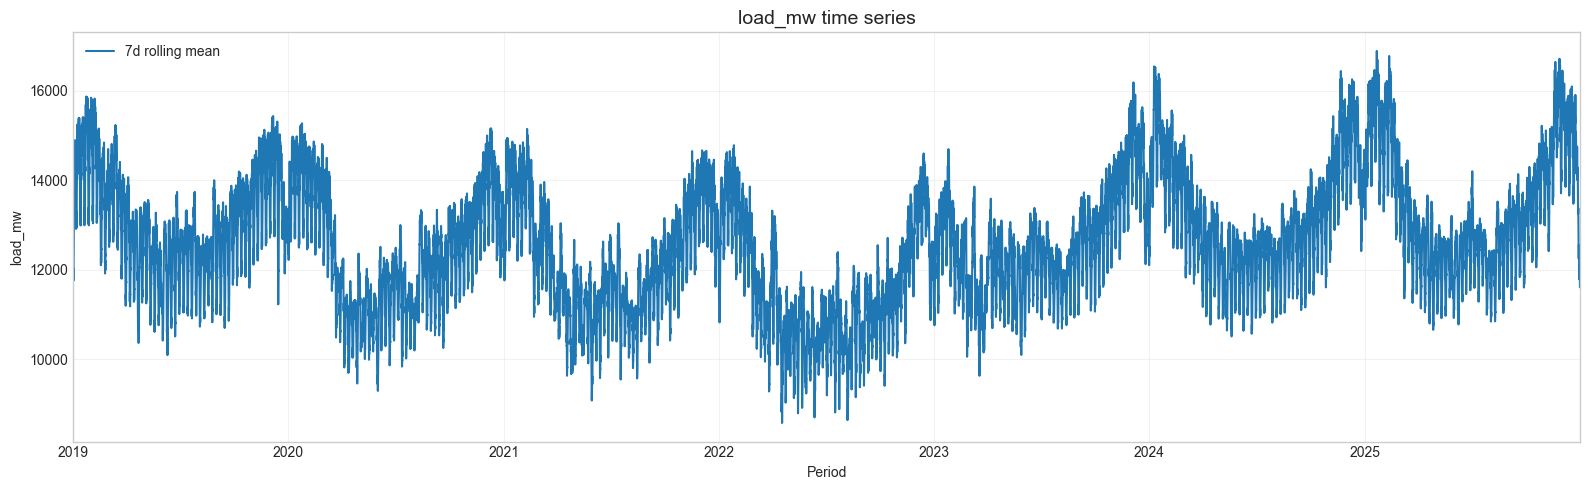


ROLLING STATS


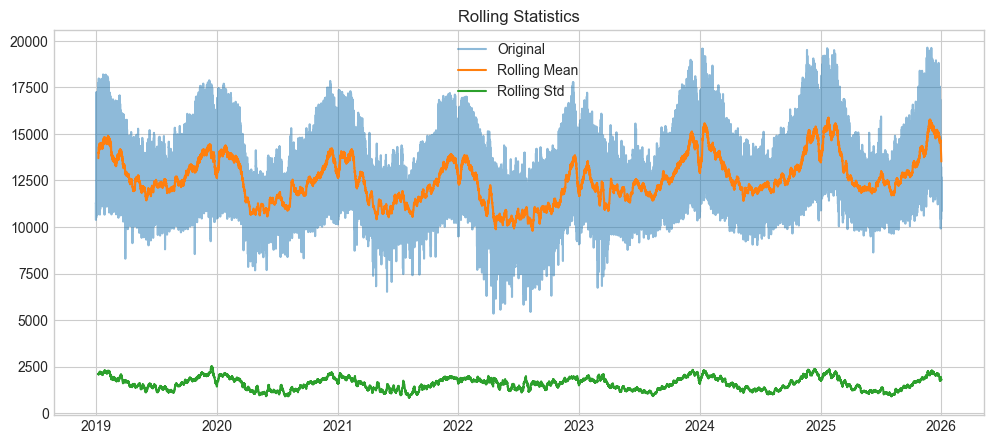


CORRELATION WITH TARGET
Pearson correlation with target: 0.0691

LAG CORRELATION WITH TARGET


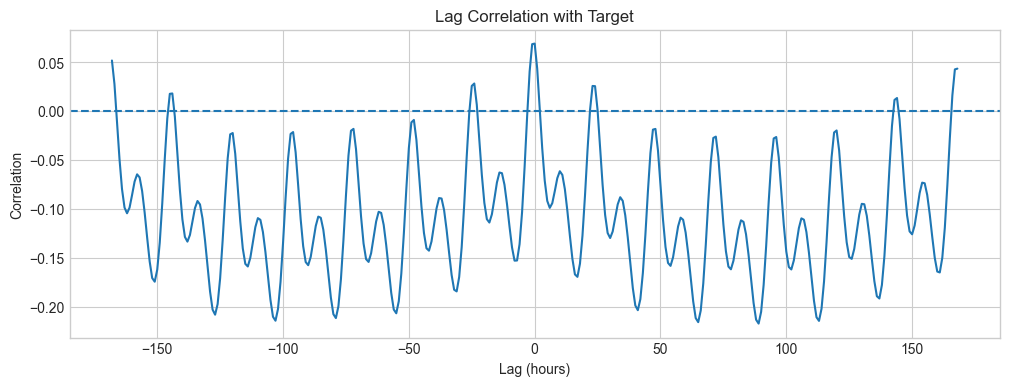

Best lag: 89 hours
Correlation at best lag: -0.2172

Best lag: 89 hours
Best lag correlation: -0.2172


In [224]:
load_ts = load_df.iloc[:, 0]
info = full_regressor_diagnostics_ts(
    load_ts,
    target_ts=price_hourly
)

Анализ временного ряда нагрузки показывает выраженную сезонную структуру на суточном и годовом уровнях, а также умеренную нестационарность среднего значения во времени. Скользящие статистики демонстрируют сезонные колебания среднего уровня нагрузки и дисперсии, при этом после 2022 года наблюдается некоторое увеличение среднего уровня нагрузки.

Прямая корреляция между нагрузкой и ценой электроэнергии является слабой (Pearson correlation около 0.07), что соответствует особенностям электроэнергетических рынков, где цена определяется не только уровнем спроса, но и структурой генерации, стоимостью топлива и состоянием энергосистемы.

Анализ лаговой корреляции показывает максимум по модулю на лаге около 89 часов (corr около -0.22). Это может отражать фазовый сдвиг между сезонными компонентами нагрузки и цены, а не прямую причинно-следственную зависимость, поэтому данный результат требует осторожной интерпретации.

В целом нагрузку следует использовать как регрессор. Несмотря на слабую линейную корреляцию с ценой, нагрузка отражает фундаментальный уровень спроса и может улучшать качество прогнозирования в сочетании с другими факторами, такими как погодные условия, возобновляемая генерация и цены топлива. Лаговая корреляция может отражать сезонные фазовые сдвиги, поэтому её следует интерпретировать с осторожностью.


BASIC TS INFO
name: solar_mw
start: 2018-12-31 23:00:00+00:00
end: 2025-12-31 22:45:00+00:00
n_rows: 245472
n_missing: 0
pct_missing: 0.0
min: 0.0
max: 428.77
mean: 44.83645241412462
std: 79.1089943694828
n_zeros: 1224
n_negative: 0
index_type: <class 'pandas.DatetimeIndex'>
n_duplicate_timestamps: 0
inferred_freq: 15min
n_missing_timestamps: 0

TREND / REGIME VIEW


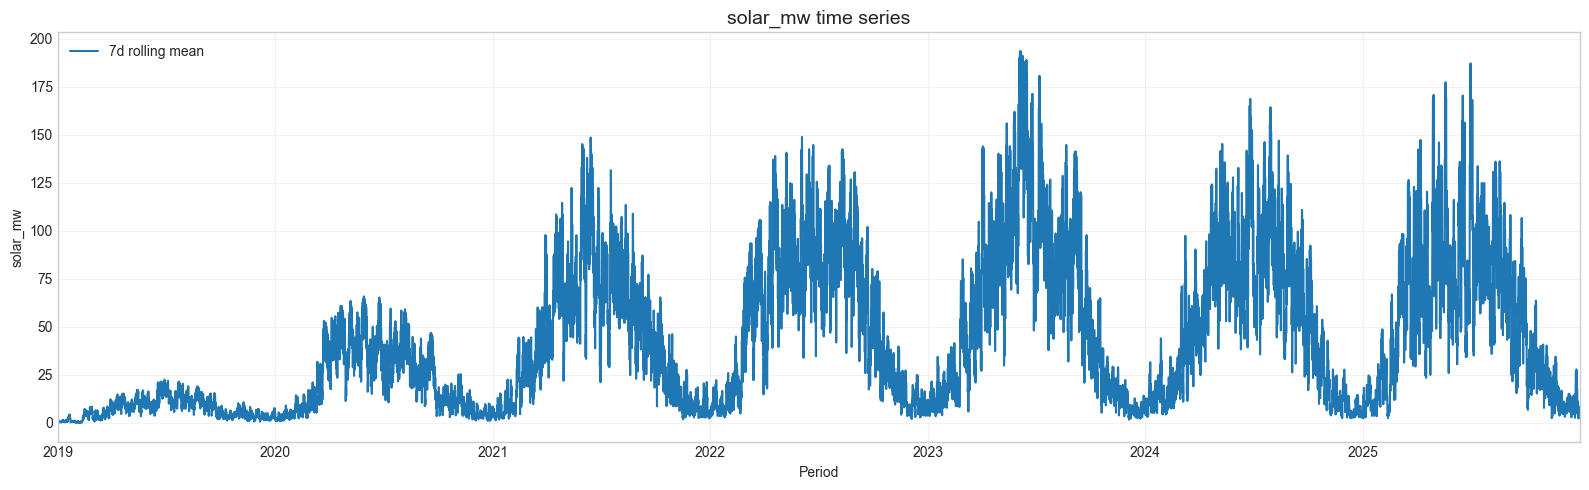


ROLLING STATS


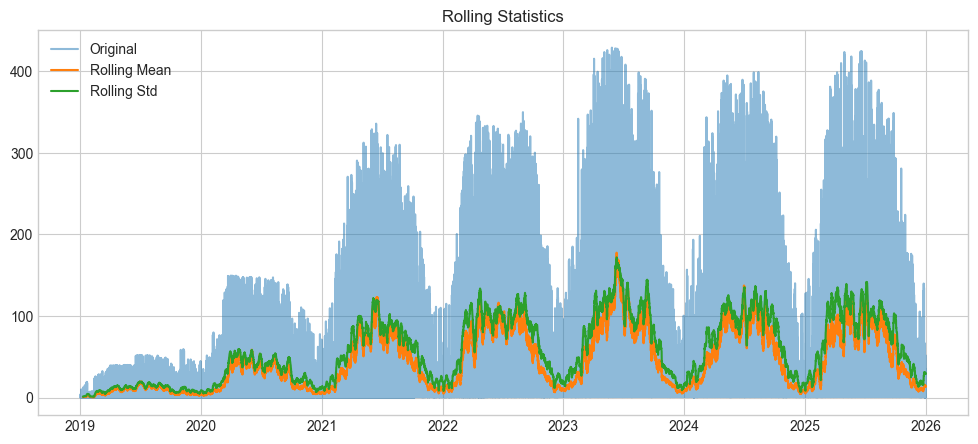


CORRELATION WITH TARGET
Pearson correlation with target: -0.0473

LAG CORRELATION WITH TARGET


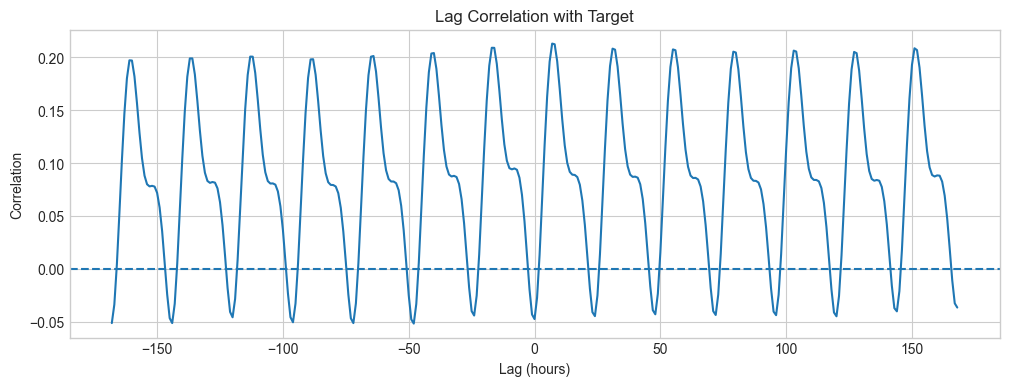

Best lag: 7 hours
Correlation at best lag: 0.2131

Best lag: 7 hours
Best lag correlation: 0.2131


In [225]:
solar_ts = solar_df.iloc[:, 0]
info = full_regressor_diagnostics_ts(
    solar_ts,
    target_ts=price_hourly
)

Анализ временного ряда солнечной генерации показывает выраженную суточную и годовую сезонность, а также рост среднего уровня генерации до 2023 года, что может отражать увеличение установленной мощности. Скользящие статистики демонстрируют изменение среднего уровня и дисперсии во времени, что указывает на нестационарность ряда.

Прямая корреляция между солнечной генерацией и ценой электроэнергии является слабой, что ожидаемо, поскольку влияние солнечной генерации на цену носит нелинейный характер и проявляется преимущественно в дневные часы через эффект merit order.

Анализ лаговой корреляции показывает максимум около 7 часов (corr около 0.21), что может отражать фазовый сдвиг между внутрисуточными паттернами генерации и цен. Данный результат следует интерпретировать с осторожностью, поскольку он не обязательно отражает причинно-следственную зависимость.


BASIC TS INFO
name: wind_mw
start: 2018-12-31 23:00:00+00:00
end: 2025-12-31 22:45:00+00:00
n_rows: 245472
n_missing: 0
pct_missing: 0.0
min: 6.83
max: 2565.17
mean: 704.8092173282491
std: 600.2358880672656
n_zeros: 0
n_negative: 0
index_type: <class 'pandas.DatetimeIndex'>
n_duplicate_timestamps: 0
inferred_freq: 15min
n_missing_timestamps: 0

TREND / REGIME VIEW


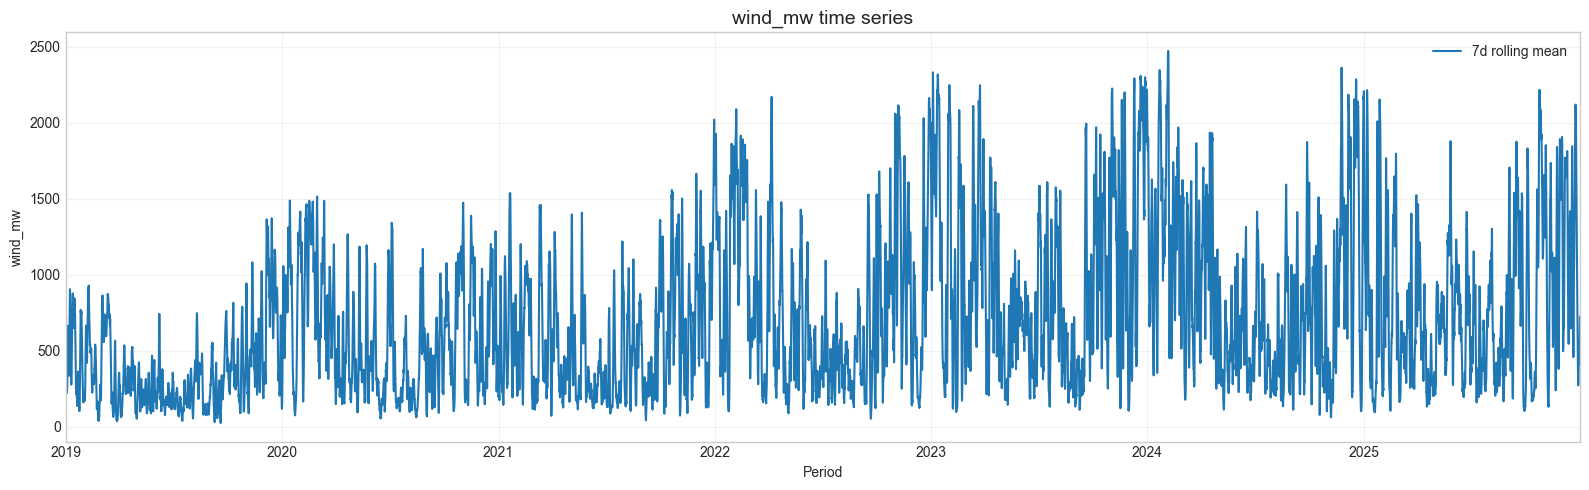


ROLLING STATS


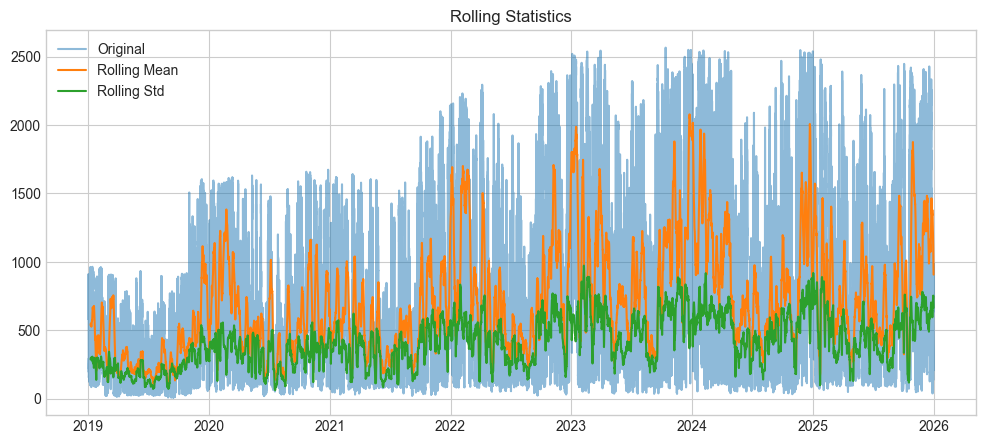


CORRELATION WITH TARGET
Pearson correlation with target: -0.1014

LAG CORRELATION WITH TARGET


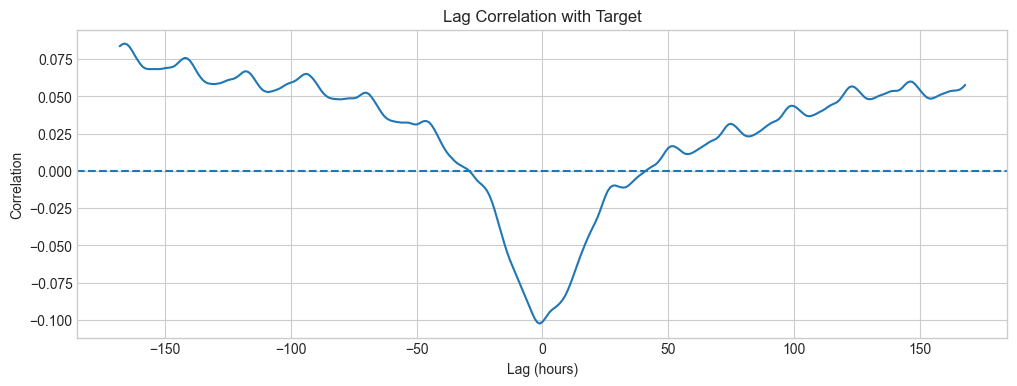

Best lag: -1 hours
Correlation at best lag: -0.1025

Best lag: -1 hours
Best lag correlation: -0.1025


In [226]:
wind_ts = wind_df.iloc[:, 0]
info = full_regressor_diagnostics_ts(
    wind_ts,
    target_ts=price_hourly
)

Анализ временного ряда ветровой генерации показывает выраженную стохастичность и сезонную изменчивость, а также постепенный рост среднего уровня генерации во времени, что может отражать увеличение установленной мощности. Скользящие статистики демонстрируют изменение среднего уровня и дисперсии, что указывает на нестационарность ряда.

Прямая корреляция между ветровой генерацией и ценой электроэнергии является слабой и отрицательной, что соответствует экономике электроэнергетического рынка: увеличение генерации с низкой предельной стоимостью снижает рыночную цену через эффект merit order.

Лаговая корреляция не демонстрирует выраженных пиков, что указывает на преимущественно одновременное влияние ветровой генерации на цену без выраженной временной задержки.


BASIC TS INFO
name: temperature_c
start: 2019-01-01 00:00:00+00:00
end: 2025-12-31 23:00:00+00:00
n_rows: 61368
n_missing: 0
pct_missing: 0.0
min: -12.1
max: 36.4
mean: 11.266119150045625
std: 6.418996201016926
n_zeros: 42
n_negative: 1796
index_type: <class 'pandas.DatetimeIndex'>
n_duplicate_timestamps: 0
inferred_freq: h
n_missing_timestamps: 0

TREND / REGIME VIEW


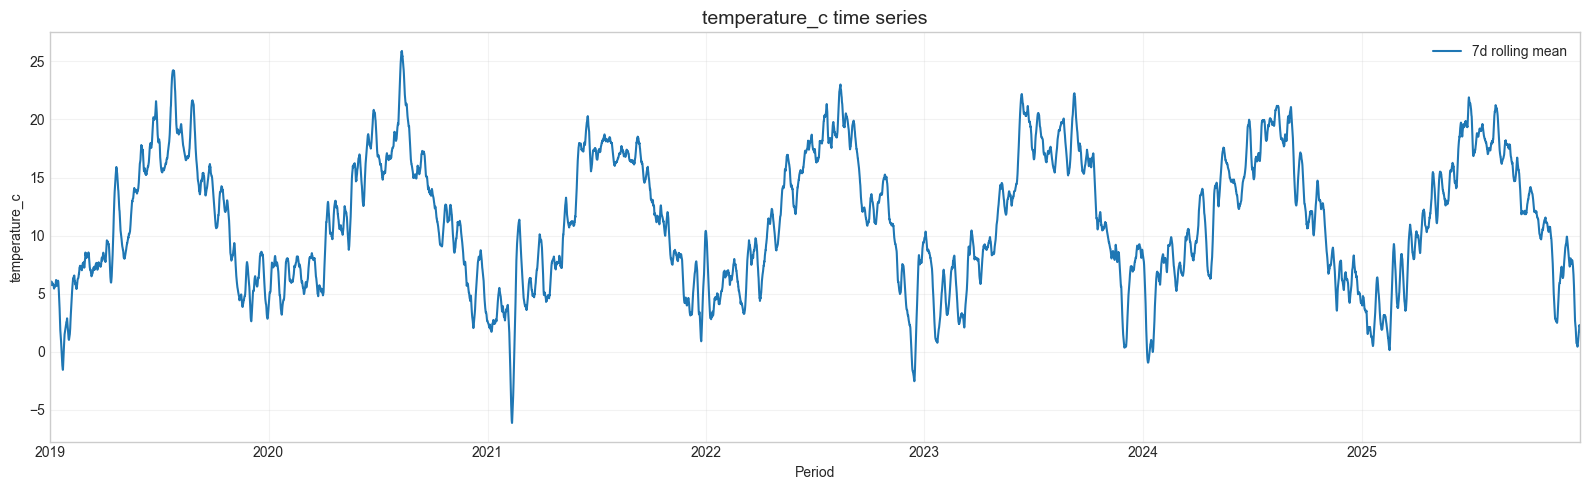


ROLLING STATS


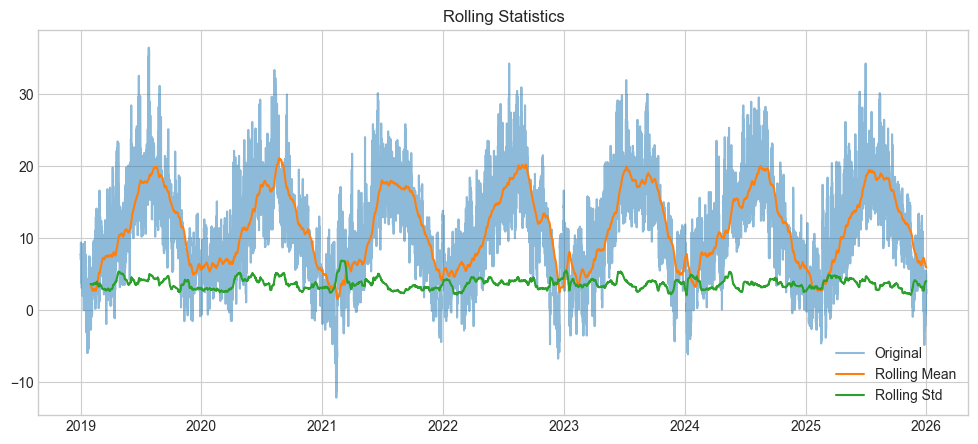


CORRELATION WITH TARGET
Pearson correlation with target: -0.0358

LAG CORRELATION WITH TARGET


/var/folders/jm/fc2yd4bx6r10m1j2gh1r3dq40000gn/T/ipykernel_23445/1201618541.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  aligned = pd.concat([ts, target_ts], axis=1).dropna()
/var/folders/jm/fc2yd4bx6r10m1j2gh1r3dq40000gn/T/ipykernel_23445/1201618541.py:16: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  aligned = pd.concat([ts, target_ts], axis=1).dropna()


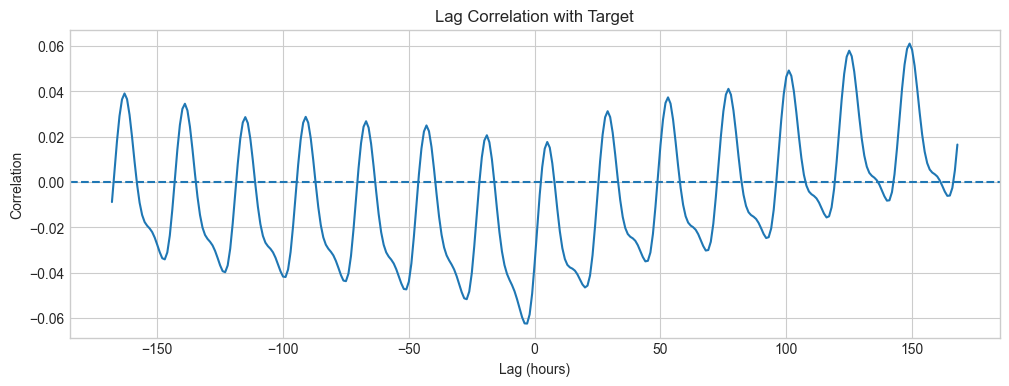

Best lag: -3 hours
Correlation at best lag: -0.0625

Best lag: -3 hours
Best lag correlation: -0.0625


In [227]:
weather_ts = weather_df.iloc[:, 0]
info = full_regressor_diagnostics_ts(
    weather_ts,
    target_ts=price_hourly
)

Анализ временного ряда температуры демонстрирует выраженную годовую сезонность при относительно стабильной дисперсии во времени. Скользящие статистики подтверждают отсутствие выраженного долгосрочного тренда и наличие регулярных сезонных колебаний.

Линейная корреляция между температурой и ценой электроэнергии является слабой, что ожидаемо, поскольку влияние температуры на цену носит преимущественно нелинейный характер и реализуется через изменение спроса на электроэнергию. В холодные и жаркие периоды наблюдается рост спроса, тогда как в периоды умеренных температур спрос снижается.

Лаговая корреляция демонстрирует сезонную структуру без выраженных пиков, что указывает на отсутствие простой временной задержки влияния температуры на цену.

#### Выводы

Несмотря на относительно слабую линейную корреляцию с ценой электроэнергии, фундаментальные регрессоры (нагрузка, возобновляемая генерация и погодные параметры) могут существенно улучшать качество почасового прогнозирования. Их вклад заключается не столько в объяснении почасовых флуктуаций, сколько в описании общего режима работы энергосистемы, сезонных эффектов и структурных изменений рынка. В сочетании с авторегрессионными компонентами такие регрессоры позволяют повысить устойчивость модели и улучшить обобщающую способность при прогнозировании в различных рыночных условиях.